# **Import Dependencies**

In [136]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
import matplotlib.ticker as ticker

from sklearn import svm, tree, linear_model, neighbors, naive_bayes, ensemble, discriminant_analysis, gaussian_process
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn import feature_selection
from sklearn.model_selection import train_test_split
from sklearn import metrics

from pycaret.classification import *

## **Data Analysis**

In [137]:
tit_df = pd.read_csv('/kaggle/input/titanic/train.csv')
tit_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [138]:
print(f"The Image contains {tit_df.shape[0]} rows and {tit_df.shape[1]} columns")

The Image contains 891 rows and 12 columns


In [139]:
tit_df.info()

<class 'pandas.core.frame.DataFrame'>

RangeIndex: 891 entries, 0 to 890

Data columns (total 12 columns):

 #   Column       Non-Null Count  Dtype  

---  ------       --------------  -----  

 0   PassengerId  891 non-null    int64  

 1   Survived     891 non-null    int64  

 2   Pclass       891 non-null    int64  

 3   Name         891 non-null    object 

 4   Sex          891 non-null    object 

 5   Age          714 non-null    float64

 6   SibSp        891 non-null    int64  

 7   Parch        891 non-null    int64  

 8   Ticket       891 non-null    object 

 9   Fare         891 non-null    float64

 10  Cabin        204 non-null    object 

 11  Embarked     889 non-null    object 

dtypes: float64(2), int64(5), object(5)

memory usage: 83.7+ KB


In [140]:
tit_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [141]:
tit_df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [142]:
tit_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [143]:
def count_plot(x, df, title, xlabel, ylabel, width, height, order = None, rotation=False, palette='winter', hue=None):
    ncount = len(df)
    plt.figure(figsize=(width,height))
    ax = sns.countplot(x = x, palette=palette, order = order, hue=hue)
    plt.title(title, fontsize=20)
    if rotation:
        plt.xticks(rotation = 'vertical')
    plt.xlabel(xlabel, fontsize=15)
    plt.ylabel(ylabel, fontsize=15)

    ax.yaxis.set_label_position('left')
    for p in ax.patches:
        x=p.get_bbox().get_points()[:,0]
        y=p.get_bbox().get_points()[1,1]
        ax.annotate('{:.1f}%'.format(100.*y/ncount), (x.mean(), y), 
                ha='center', va='bottom') # set the alignment of the text

    plt.show()

In [144]:
tit_df['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

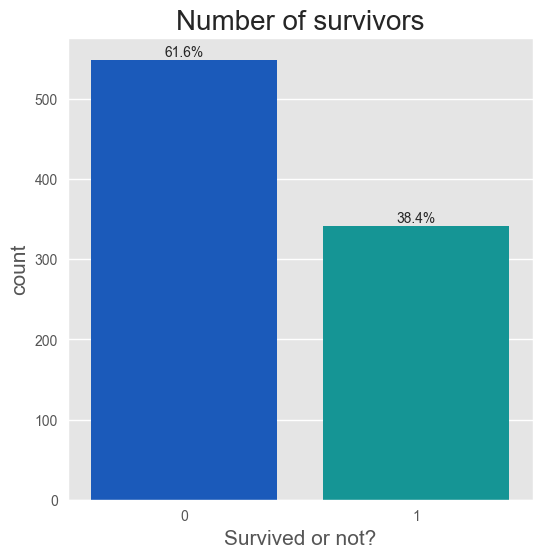

In [145]:
x = tit_df['Survived']
count_plot(x, tit_df, "Number of survivors", "Survived or not?", "count", 6,6)

### **Only 38.4% Survived from Titanic Disaster**

In [146]:
tit_df['Sex'].value_counts()

male      577
female    314
Name: Sex, dtype: int64

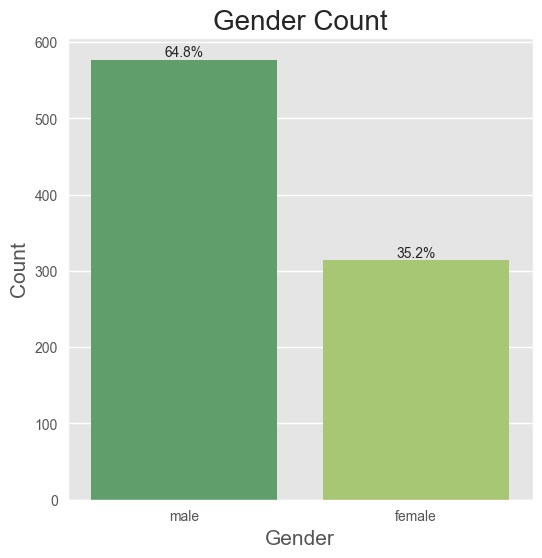

In [147]:
x = tit_df['Sex']
count_plot(x, tit_df, "Gender Count", "Gender", 'Count', 6,6, palette='summer')

### **Titanic had more men (64.8%) than women (35.2%)**

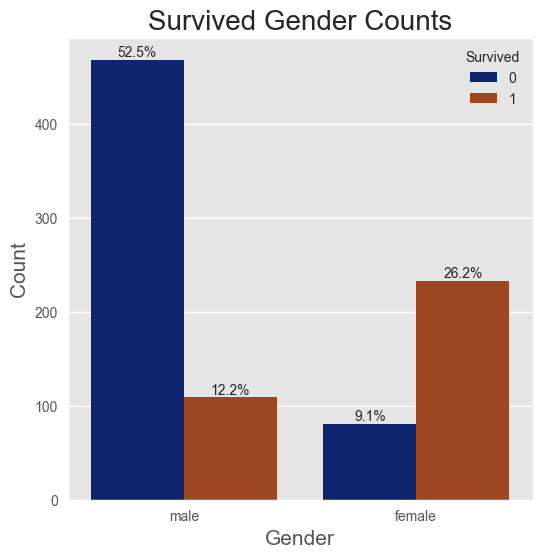

In [148]:
x = tit_df['Sex']
hue = tit_df['Survived']
count_plot(x, tit_df, "Survived Gender Counts", "Gender", 'Count', 6,6, palette='dark', hue=hue)

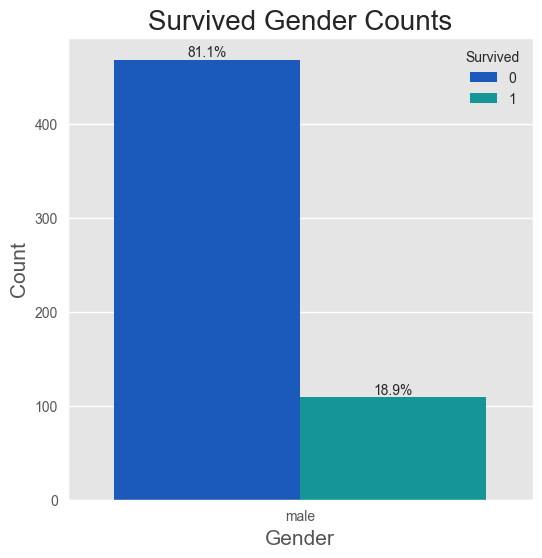

In [149]:
male_df = tit_df[tit_df['Sex'] == 'male']
x = male_df['Sex']
hue = male_df['Survived']
count_plot(x, male_df, "Survived Gender Counts", "Gender", 'Count', 6,6, palette='winter', hue=hue)

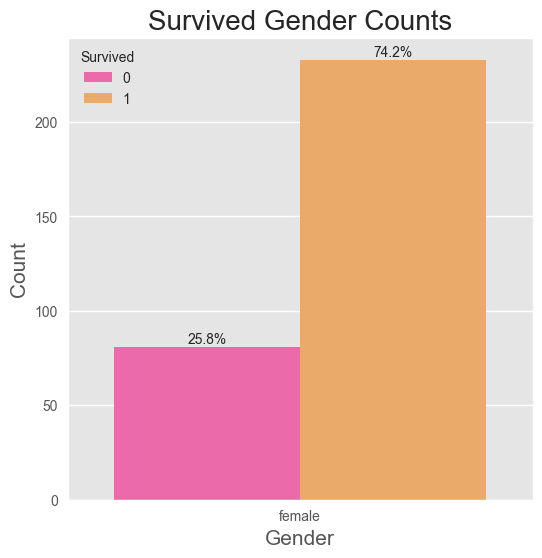

In [150]:
female_df = tit_df[tit_df['Sex'] == 'female']
x = female_df['Sex']
hue = female_df['Survived']
count_plot(x, female_df, "Survived Gender Counts", "Gender", 'Count', 6,6, palette='spring', hue=hue)

### **Only 19% of males survived while 74.2% females survived**

In [151]:
tit_df['Pclass'].value_counts()

3    491
1    216
2    184
Name: Pclass, dtype: int64

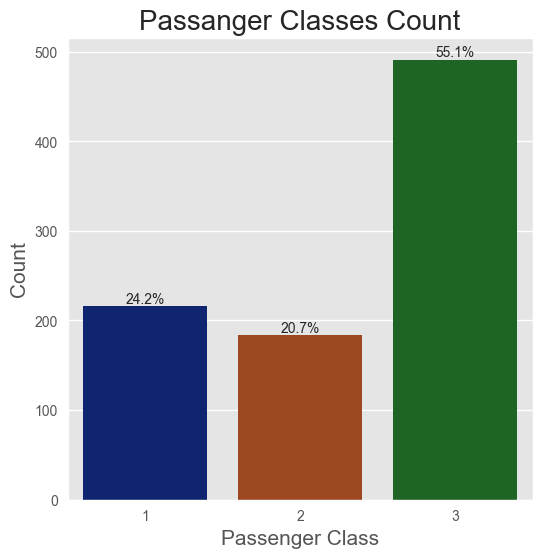

In [152]:
x = tit_df['Pclass']
count_plot(x, tit_df, "Passanger Classes Count", "Passenger Class", 'Count', 6,6, palette='dark')

### **55.1% of the passengers was 3rd class, 20.7% was 2nd class and finally 24.2% are 1st class**

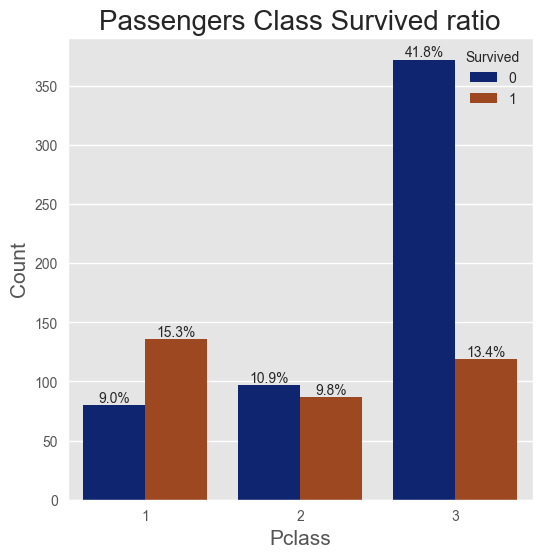

In [153]:
x = tit_df['Pclass']
hue = tit_df['Survived']
count_plot(x, tit_df, "Passengers Class Survived ratio", "Pclass", 'Count', 6,6, palette='dark', hue=hue)

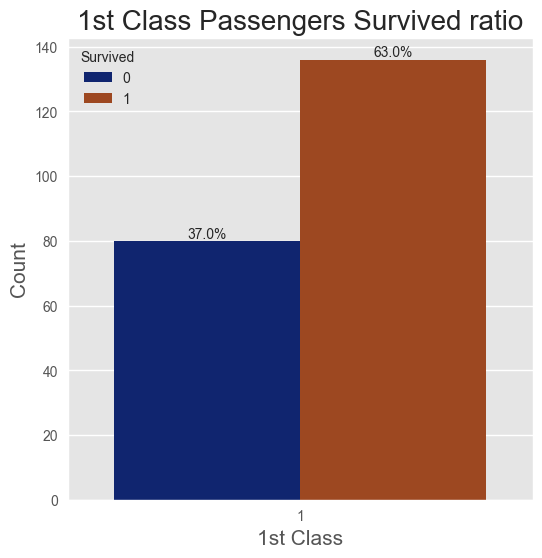

In [154]:
first_classP = tit_df[tit_df['Pclass'] == 1]
x = first_classP['Pclass']
hue = first_classP['Survived']
count_plot(x, first_classP, "1st Class Passengers Survived ratio", "1st Class", 'Count', 6,6, palette='dark', hue=hue)

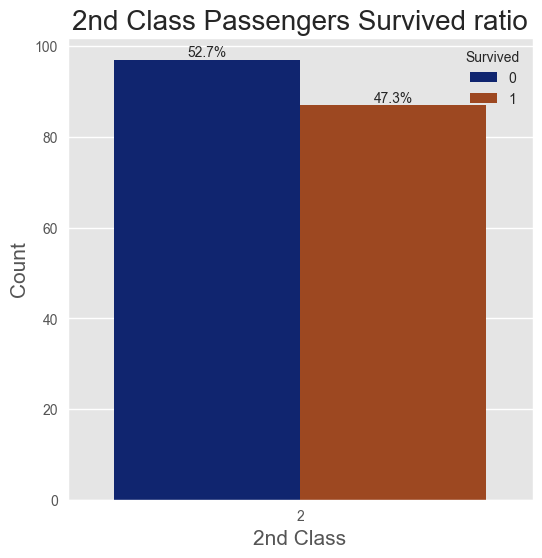

In [155]:
second_classP = tit_df[tit_df['Pclass'] == 2]
x = second_classP['Pclass']
hue = second_classP['Survived']
count_plot(x, second_classP, "2nd Class Passengers Survived ratio", "2nd Class", 'Count', 6,6, palette='dark', hue=hue)

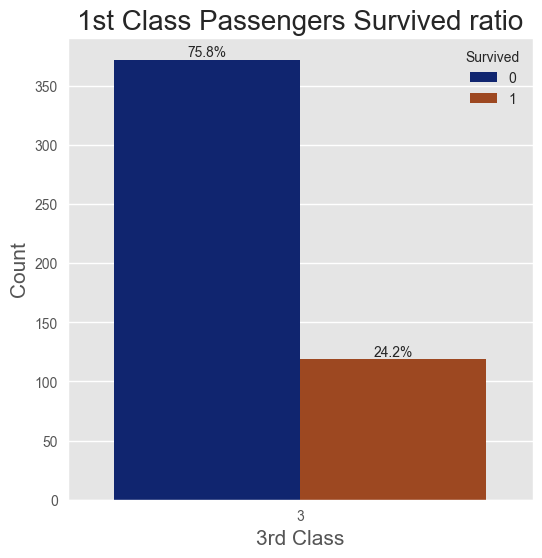

In [156]:
third_classP = tit_df[tit_df['Pclass'] == 3]
x = third_classP['Pclass']
hue = third_classP['Survived']
count_plot(x, third_classP, "1st Class Passengers Survived ratio", "3rd Class", 'Count', 6,6, palette='dark', hue=hue)

### **63% of 1st class Passengers Survived**
### **47% of 2nd class Passengers Survived**
### **24% of 3rd class Passengers Survived**

In [157]:
tit_df.Embarked.value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

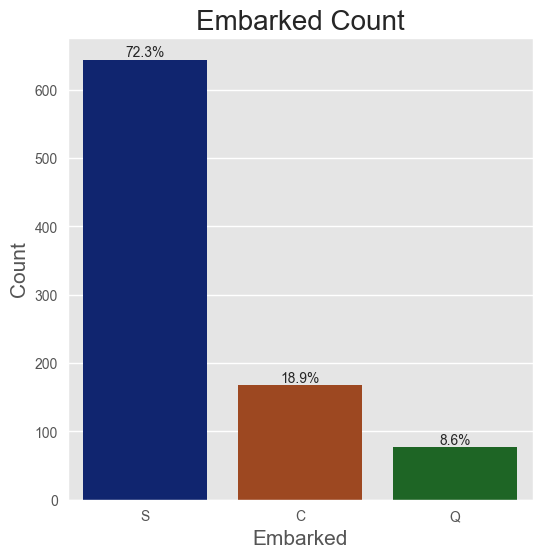

In [158]:
x = tit_df['Embarked']
count_plot(x, tit_df, "Embarked Count", "Embarked", 'Count', 6,6, palette='dark')

### **72.3% of the people boarded from Southampton.**
### **18.9% of the people boarded from Cherbourg.**
### **8.6% of the people boarded from Queenstown.**

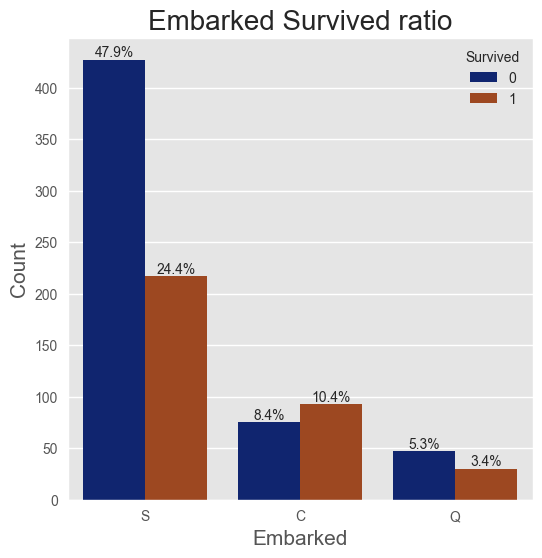

In [159]:
x = tit_df['Embarked']
hue = tit_df['Survived']
count_plot(x,tit_df, "Embarked Survived ratio", "Embarked", 'Count', 6,6, palette='dark', hue=hue)

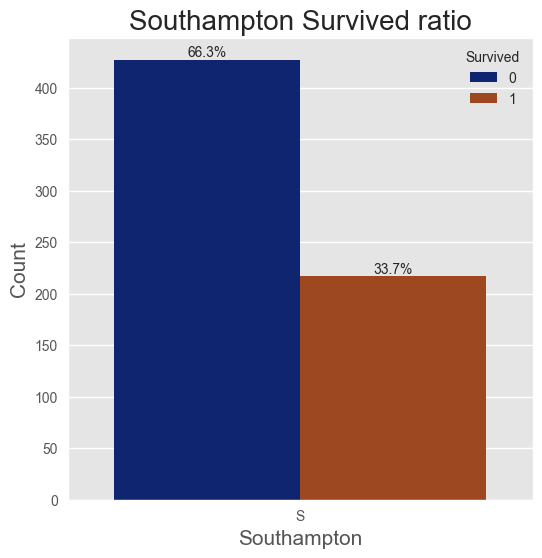

In [160]:
southampton = tit_df[tit_df['Embarked'] == 'S']
x = southampton['Embarked']
hue = southampton['Survived']
count_plot(x,southampton, "Southampton Survived ratio", "Southampton", 'Count', 6,6, palette='dark', hue=hue)

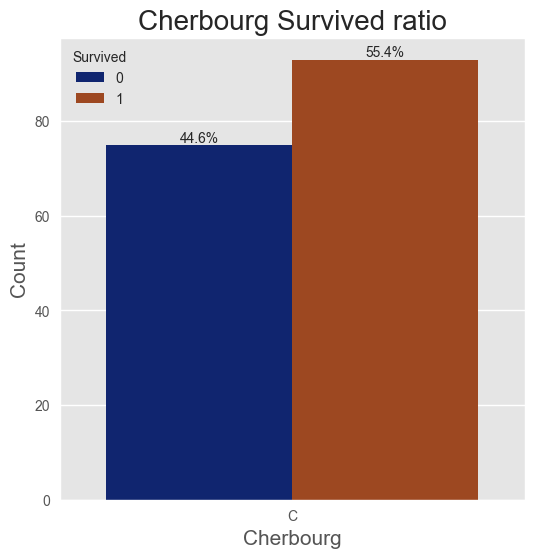

In [161]:
cherbourg = tit_df[tit_df['Embarked'] == 'C']
x = cherbourg['Embarked']
hue = cherbourg['Survived']
count_plot(x,cherbourg, "Cherbourg Survived ratio", "Cherbourg", 'Count', 6,6, palette='dark', hue=hue)

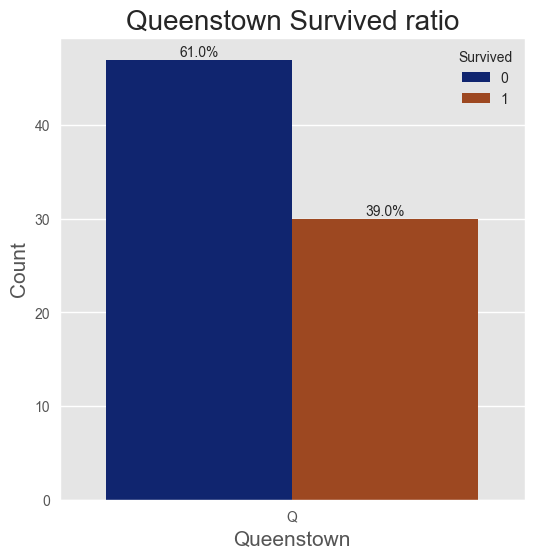

In [162]:
queenstown = tit_df[tit_df['Embarked'] == 'Q']
x = queenstown['Embarked']
hue = queenstown['Survived']
count_plot(x,queenstown, "Queenstown Survived ratio", "Queenstown", 'Count', 6,6, palette='dark', hue=hue)

### **33.7% of the people boarded from Southampton has Survived.**
### **55.4% of the people boarded from Cherbourg has Survived.**
### **39% of the people boarded from Queenstown has Survived.**

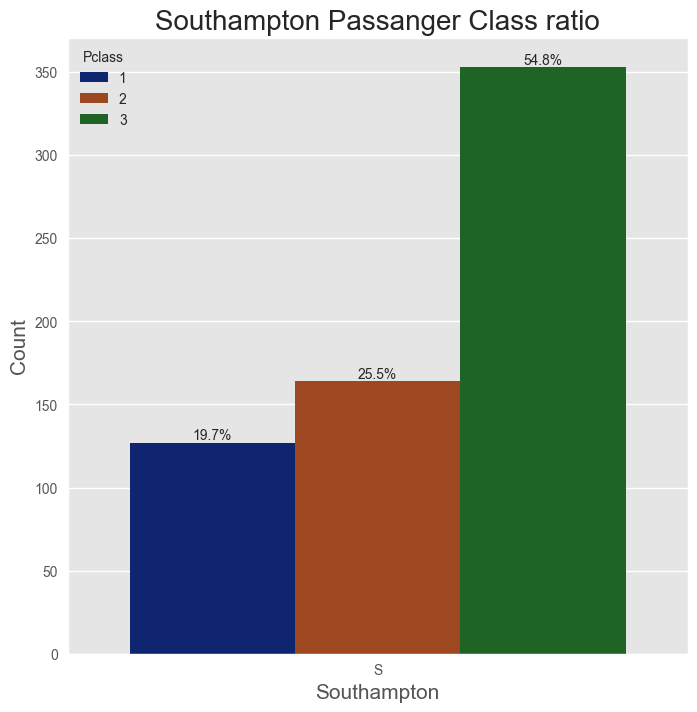

In [163]:
southampton = tit_df[tit_df['Embarked'] == 'S']
x = southampton['Embarked']
hue = southampton['Pclass']
count_plot(x,southampton, "Southampton Passanger Class ratio", "Southampton", 'Count', 8,8, palette='dark', hue=hue)

### **54.8% of the people boarded from Southampton are 3rd Class, 25.5% are 2nd Class, 19.7% are 1st Class**

### **Most of the pepole boarded from Southampton are 3rd Class**


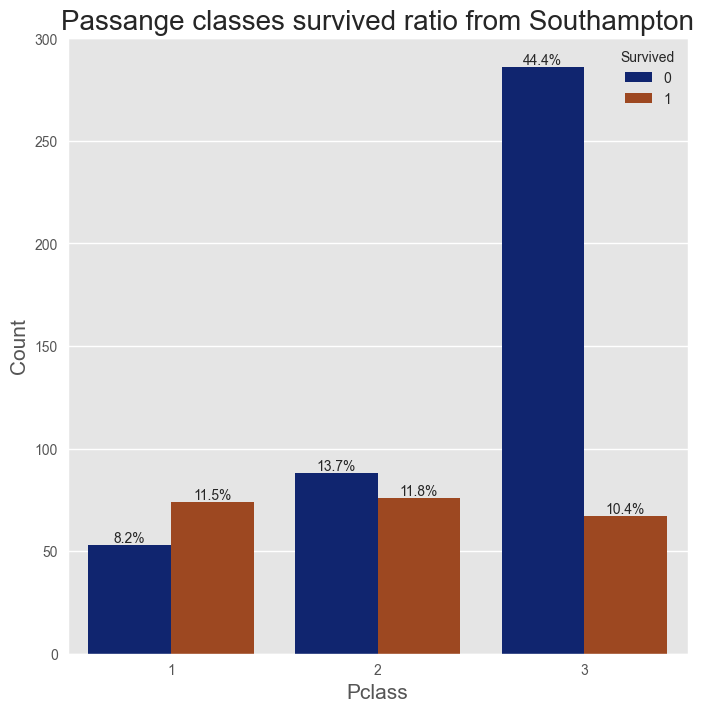

In [164]:
southampton = tit_df[tit_df['Embarked'] == 'S']
x = southampton['Pclass']
hue = southampton['Survived']
count_plot(x,southampton, "Passange classes survived ratio from Southampton", "Pclass", 'Count', 8,8, palette='dark', hue=hue)

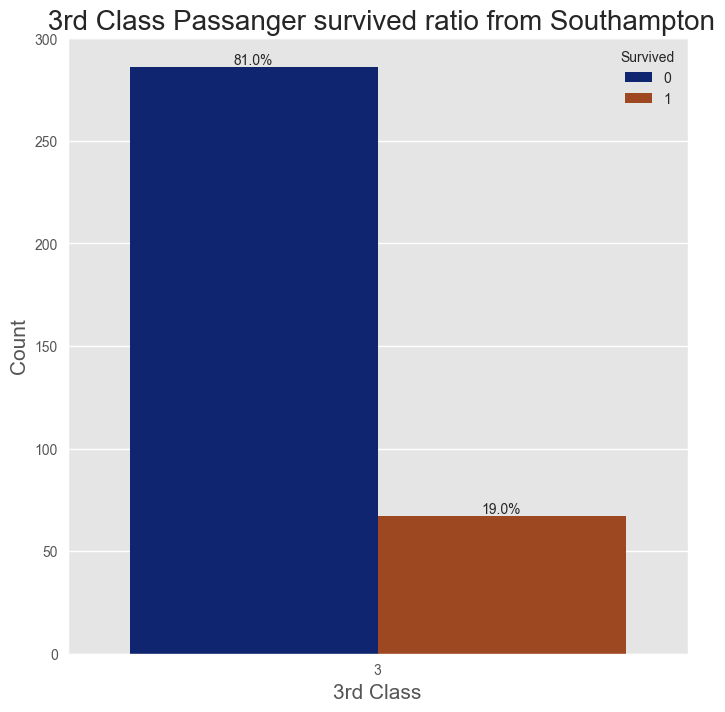

In [165]:
southampton = tit_df[ (tit_df['Embarked'] == 'S') & (tit_df['Pclass'] == 3)]
x = southampton['Pclass']
hue = southampton['Survived']
count_plot(x,southampton, " 3rd Class Passanger survived ratio from Southampton", "3rd Class", 'Count', 8,8, palette='dark', hue=hue)

### **Only 19% of the 3rd Class people boarded from Southampton Survived**


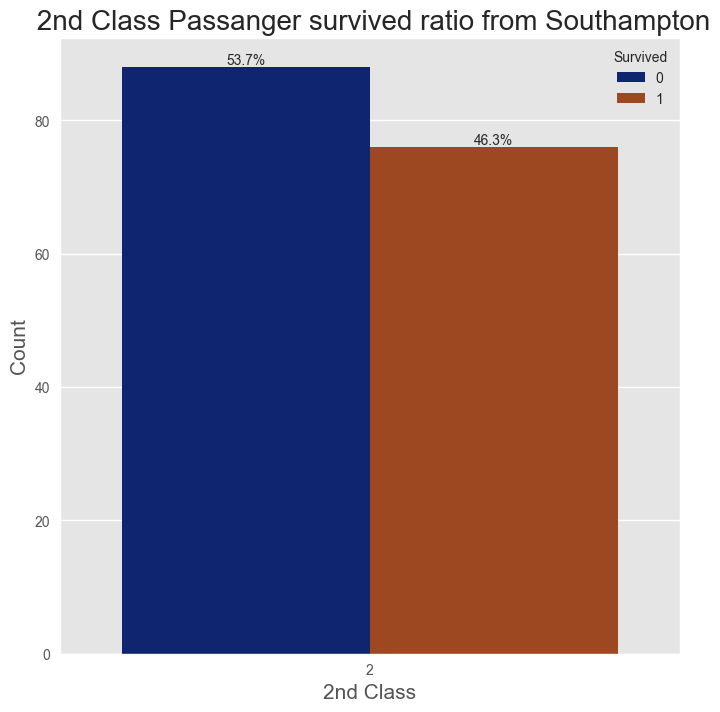

In [166]:
southampton = tit_df[ (tit_df['Embarked'] == 'S') & (tit_df['Pclass'] == 2)]
x = southampton['Pclass']
hue = southampton['Survived']
count_plot(x,southampton, " 2nd Class Passanger survived ratio from Southampton", "2nd Class", 'Count', 8,8, palette='dark', hue=hue)

### **46.3% of the 2md Class people boarded from Southampton Survived**

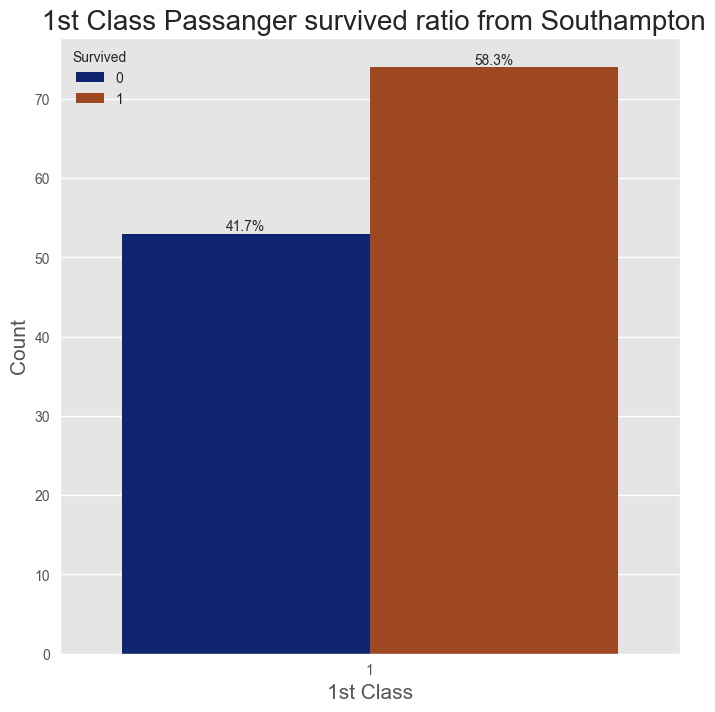

In [167]:
southampton = tit_df[ (tit_df['Embarked'] == 'S') & (tit_df['Pclass'] == 1)]
x = southampton['Pclass']
hue = southampton['Survived']
count_plot(x,southampton, " 1st Class Passanger survived ratio from Southampton", "1st Class", 'Count', 8,8, palette='dark', hue=hue)

### **58.3% of the 1st Class people boarded from Southampton Survived**

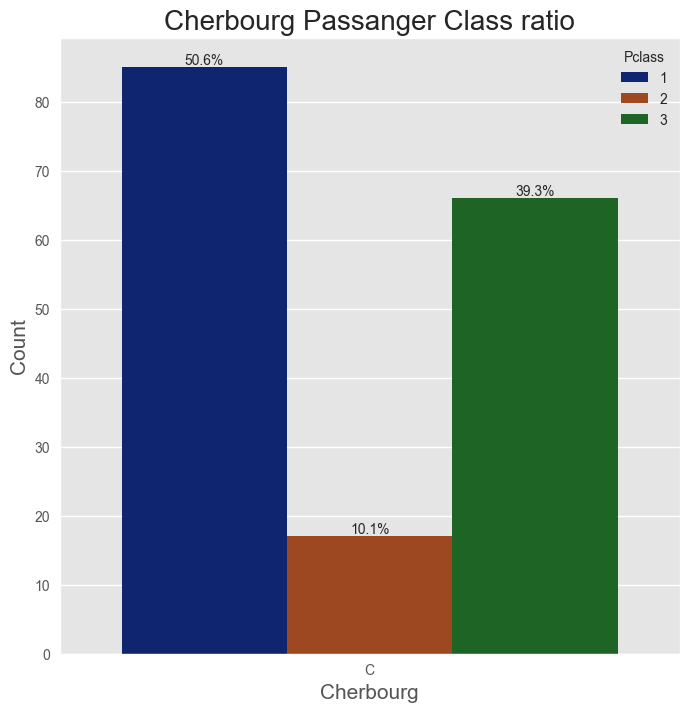

In [168]:
cherbourg = tit_df[tit_df['Embarked'] == 'C']
x = cherbourg['Embarked']
hue = cherbourg['Pclass']
count_plot(x,cherbourg, "Cherbourg Passanger Class ratio", "Cherbourg", 'Count', 8,8, palette='dark', hue=hue)

### **50.6% of the people boarded from Cherbourg are 1st Class, 10.1% are 2nd Class, 39.3% are 3rd Class**

### **Most of the pepole boarded from Cherbourg are 1st Class**

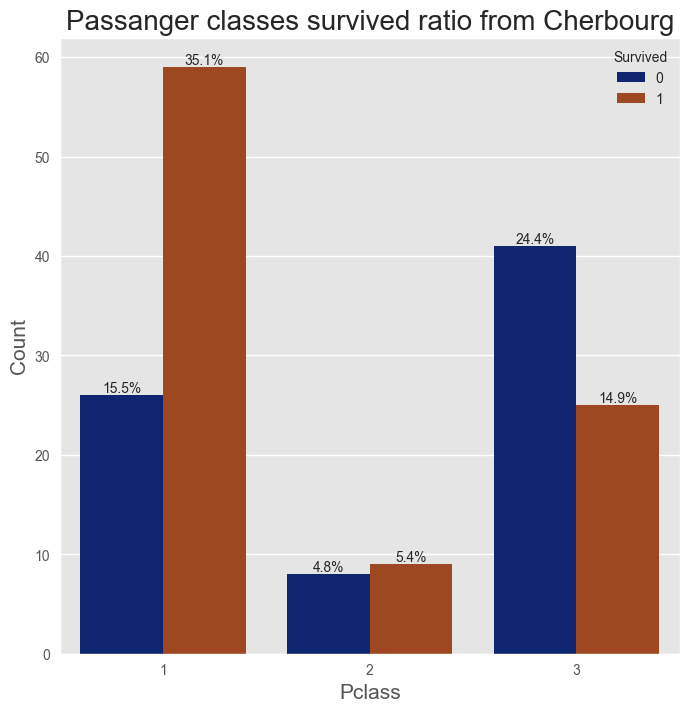

In [169]:
cherbourg = tit_df[tit_df['Embarked'] == 'C']
x = cherbourg['Pclass']
hue = cherbourg['Survived']
count_plot(x,cherbourg, "Passanger classes survived ratio from Cherbourg", "Pclass", 'Count', 8,8, palette='dark', hue=hue)

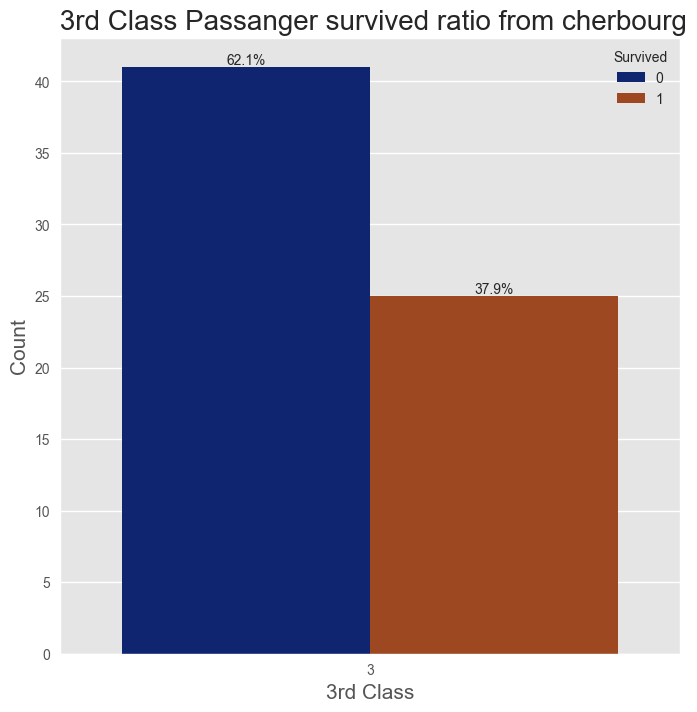

In [170]:
cherbourg = tit_df[ (tit_df['Embarked'] == 'C') & (tit_df['Pclass'] == 3)]
x = cherbourg['Pclass']
hue = cherbourg['Survived']
count_plot(x,cherbourg, " 3rd Class Passanger survived ratio from cherbourg", "3rd Class", 'Count', 8,8, palette='dark', hue=hue)

### **38% of the 3rd Class people boarded from Cherbourg Survived**

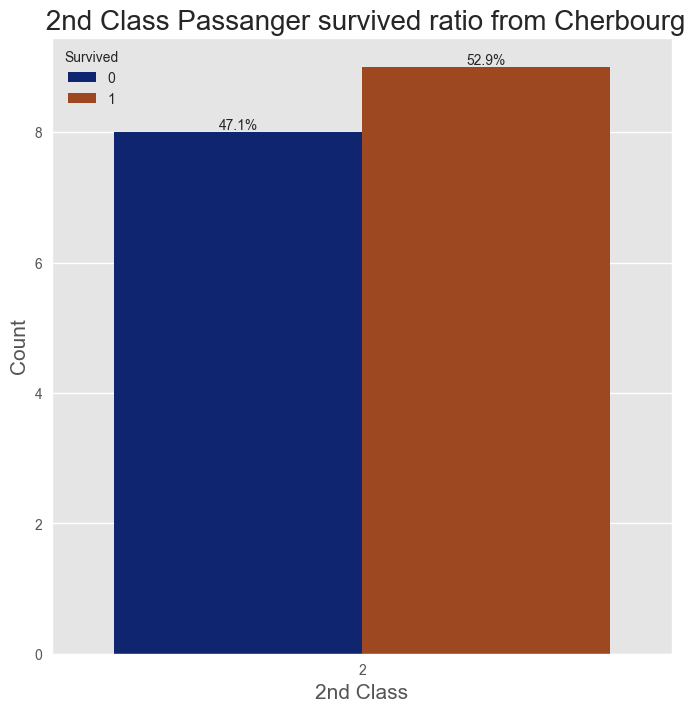

In [171]:
cherbourg = tit_df[ (tit_df['Embarked'] == 'C') & (tit_df['Pclass'] == 2)]
x = cherbourg['Pclass']
hue = cherbourg['Survived']
count_plot(x,cherbourg, " 2nd Class Passanger survived ratio from Cherbourg", "2nd Class", 'Count', 8,8, palette='dark', hue=hue)

### **53% of the 2nd Class people boarded from Cherbourg Survived**

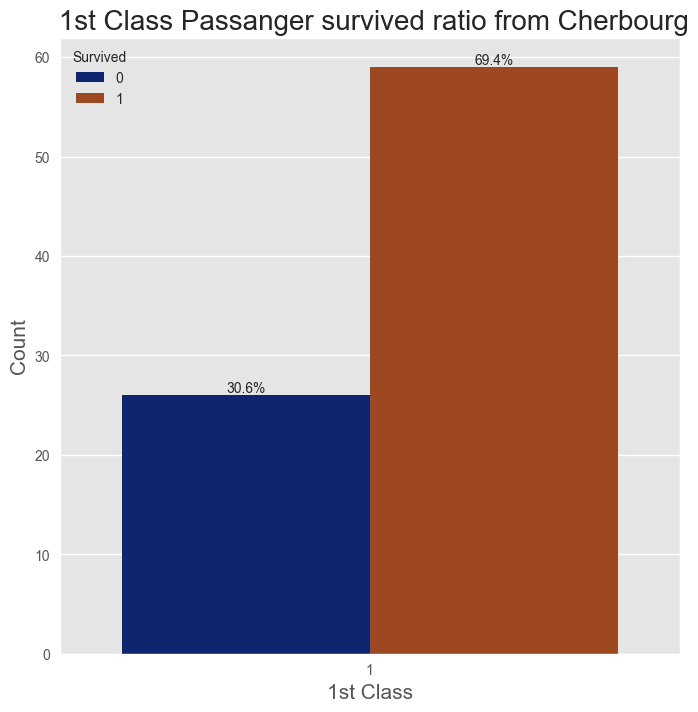

In [172]:
cherbourg = tit_df[ (tit_df['Embarked'] == 'C') & (tit_df['Pclass'] == 1)]
x = cherbourg['Pclass']
hue = cherbourg['Survived']
count_plot(x,cherbourg, " 1st Class Passanger survived ratio from Cherbourg", "1st Class", 'Count', 8,8, palette='dark', hue=hue)

### **69.4% of the 1st Class people boarded from Cherbourg Survived**

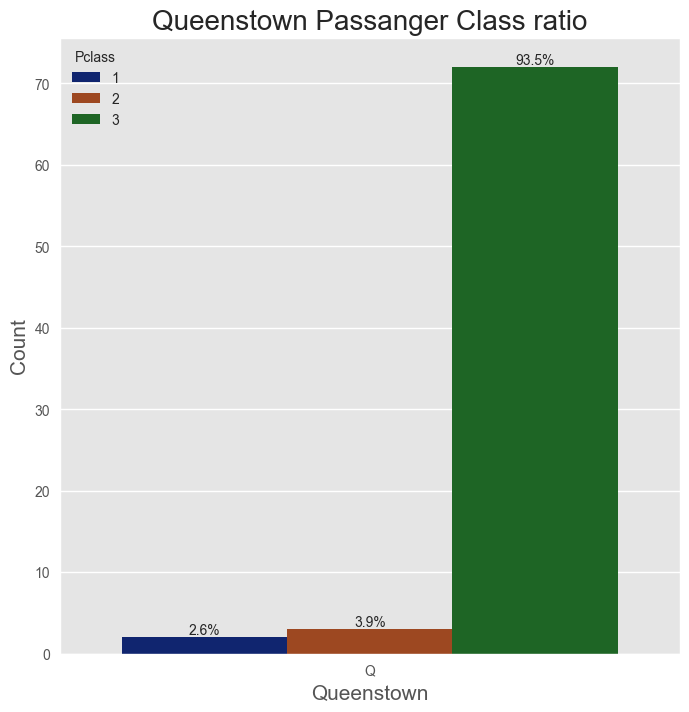

In [173]:
queenstown = tit_df[tit_df['Embarked'] == 'Q']
x = queenstown['Embarked']
hue = queenstown['Pclass']
count_plot(x,queenstown, "Queenstown Passanger Class ratio", "Queenstown", 'Count', 8,8, palette='dark', hue=hue)

### **93.5% of the people boarded from Queenstow are 3rd Class**

### **Almost all of the pepole boarded from Queenstow are 3rd Class**

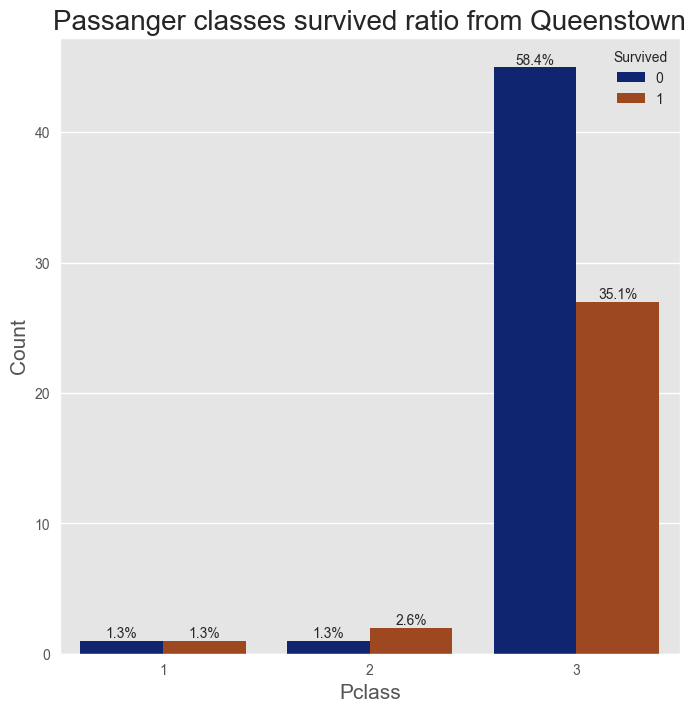

In [174]:
queenstown = tit_df[tit_df['Embarked'] == 'Q']
x = queenstown['Pclass']
hue = queenstown['Survived']
count_plot(x,queenstown, "Passanger classes survived ratio from Queenstown", "Pclass", 'Count', 8,8, palette='dark', hue=hue)

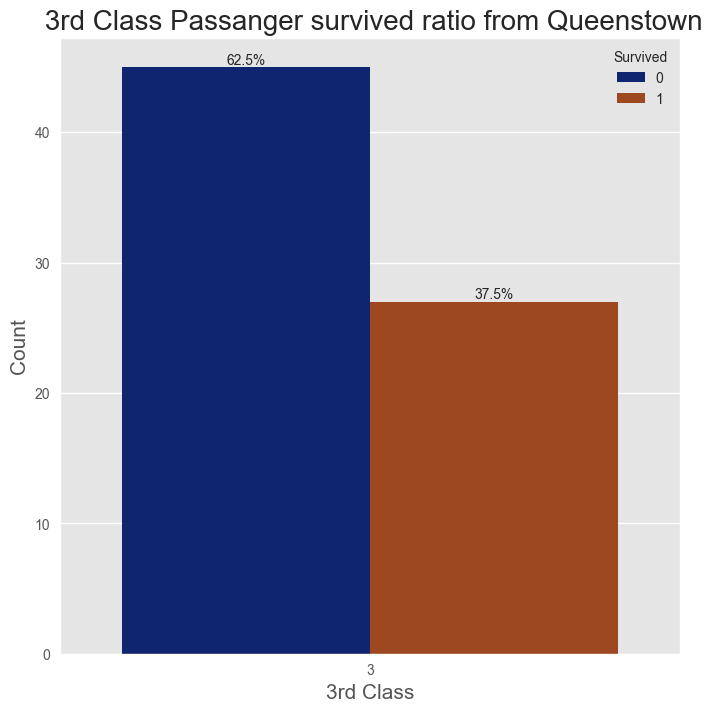

In [175]:
queenstown = tit_df[ (tit_df['Embarked'] == 'Q') & (tit_df['Pclass'] == 3)]
x = queenstown['Pclass']
hue = queenstown['Survived']
count_plot(x,queenstown, " 3rd Class Passanger survived ratio from Queenstown", "3rd Class", 'Count', 8,8, palette='dark', hue=hue)

### **37.5% of the 3rd Class people boarded from Queenstown Survived**

In [176]:
tit_df['SibSp'].value_counts()

0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: SibSp, dtype: int64

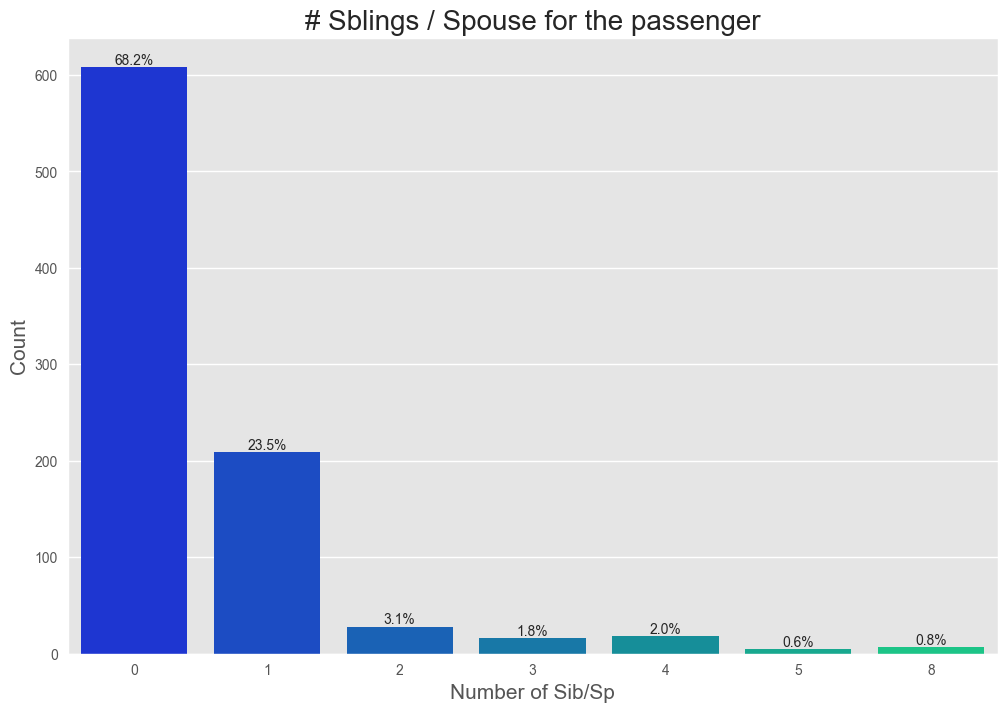

In [177]:
x = tit_df['SibSp']
order = [0,1,2,3,4,5,8]
count_plot(x, tit_df, "# Sblings / Spouse for the passenger", "Number of Sib/Sp", 'Count', 12,8, order=order, )

### **68% of the Passengers are there without Siblings or Spouse**
### **23.5% of the Passengers have 1 Sib/Sp (and Mostly it will be his/her spouse)**

In [178]:
tit_df['Parch'].value_counts()

0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: Parch, dtype: int64

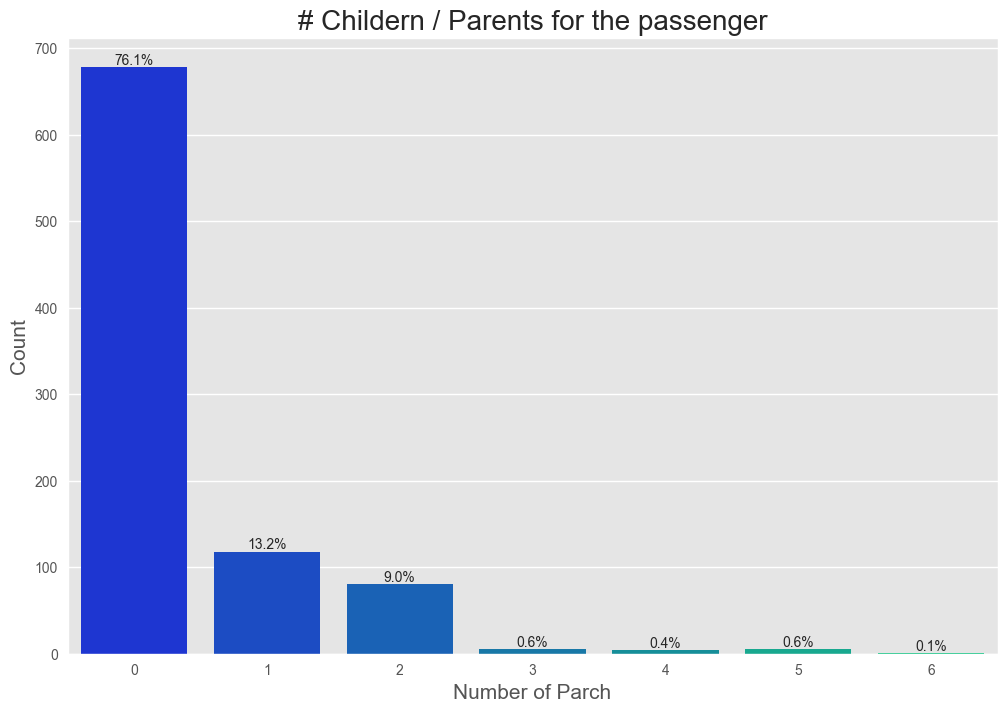

In [179]:
x = tit_df['Parch']
count_plot(x, tit_df, "# Childern / Parents for the passenger", "Number of Parch", 'Count', 12,8)

### **76% of the Passengers are there without Children or Parents**

In [180]:
tit_df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

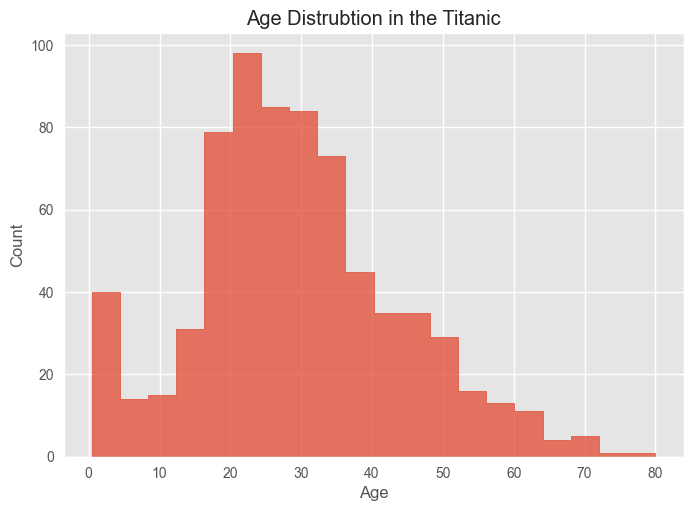

In [181]:
sns.histplot(data = tit_df, x='Age', element="step")
plt.title("Age Distrubtion in the Titanic")
plt.show()

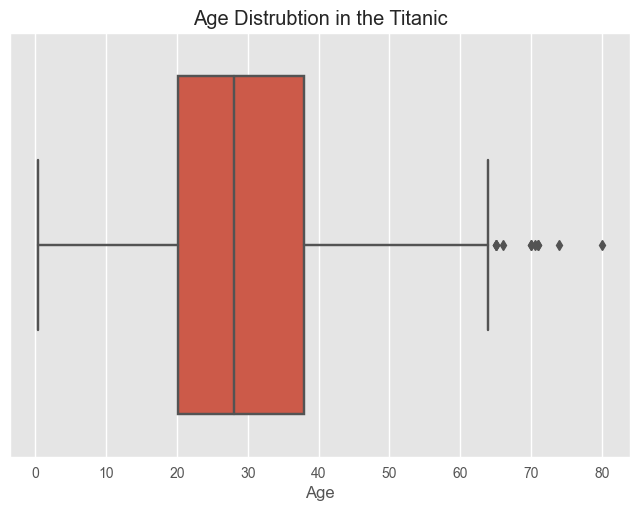

In [182]:
sns.boxplot(data = tit_df, x='Age')
plt.title("Age Distrubtion in the Titanic")
plt.show()

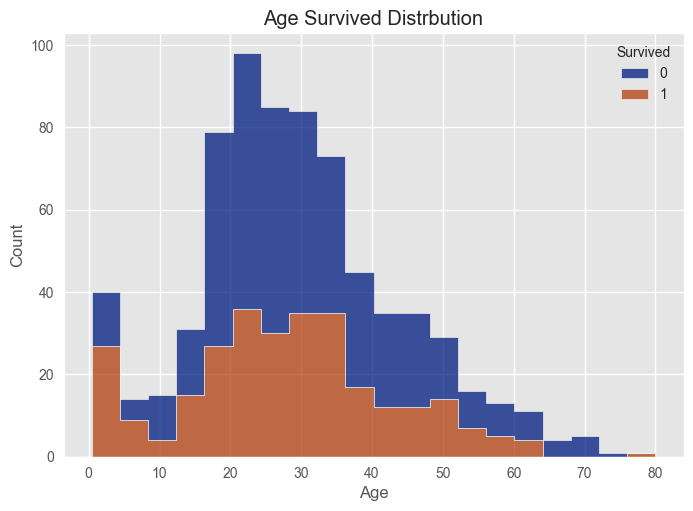

In [183]:
sns.histplot(data = tit_df, x='Age', hue='Survived', palette='dark', multiple="stack", element="step")
plt.title('Age Survived Distrbution')
plt.show()

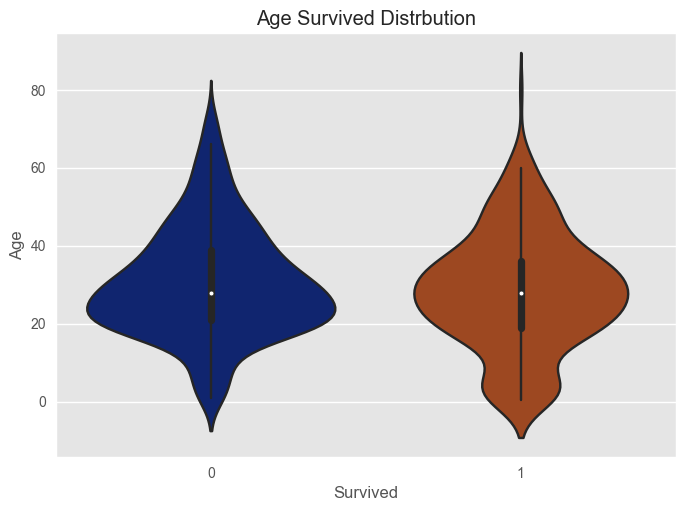

In [184]:
sns.violinplot(data = tit_df, x ='Survived', y='Age', palette='dark')
plt.title('Age Survived Distrbution')
plt.show()

### **As we see that children are the most rescued age group**

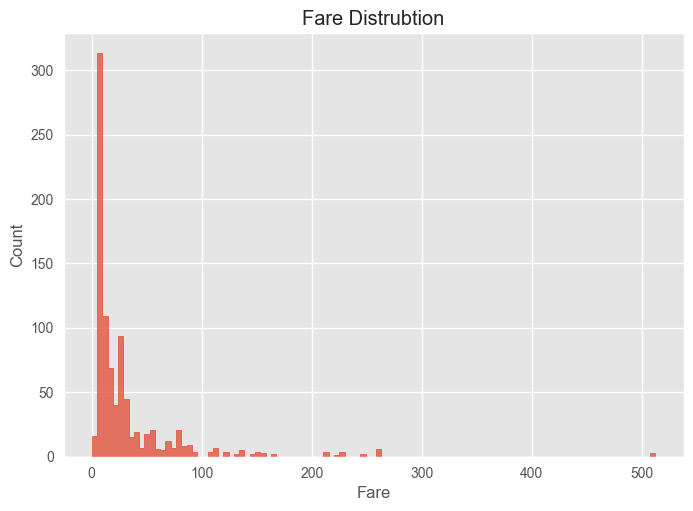

In [185]:
sns.histplot(data = tit_df, x='Fare', element="step")
plt.title("Fare Distrubtion")
plt.show()

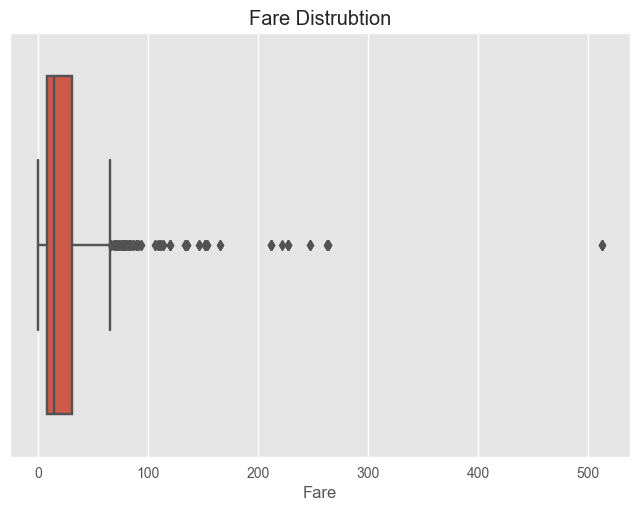

In [186]:
sns.boxplot(data = tit_df, x='Fare')
plt.title("Fare Distrubtion")
plt.show()

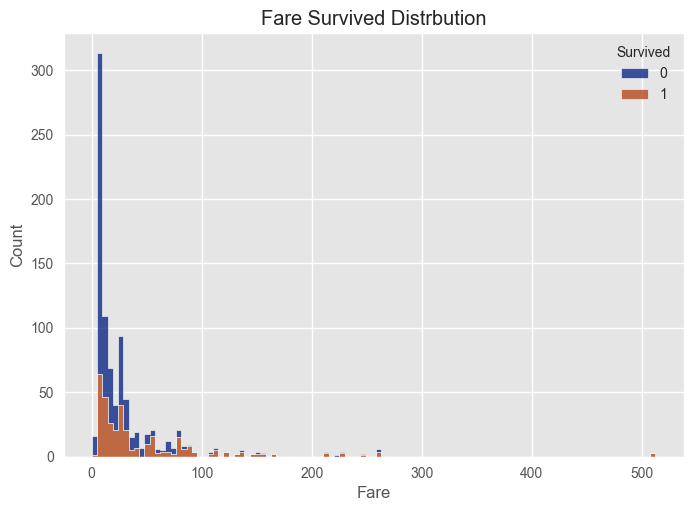

In [187]:
sns.histplot(data = tit_df, x='Fare', hue='Survived', palette='dark', multiple="stack", element="step")
plt.title('Fare Survived Distrbution')
plt.show()

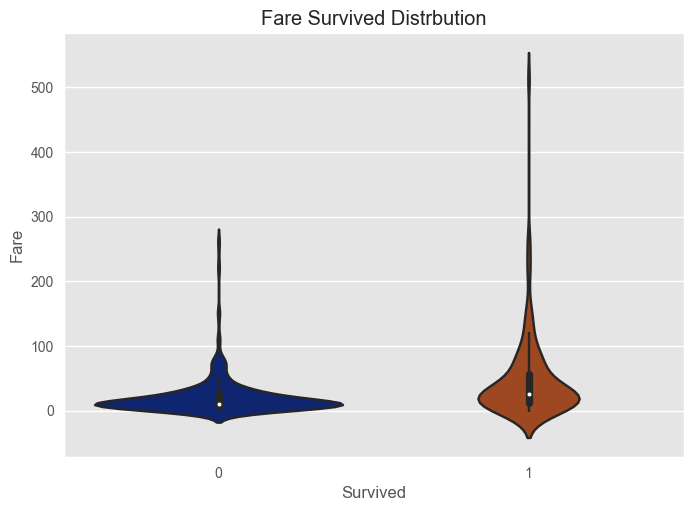

In [188]:
sns.violinplot(data = tit_df, x ='Survived', y='Fare', palette='dark')
plt.title('Fare Survived Distrbution')
plt.show()

### **As we see that children are the most rescued age group**

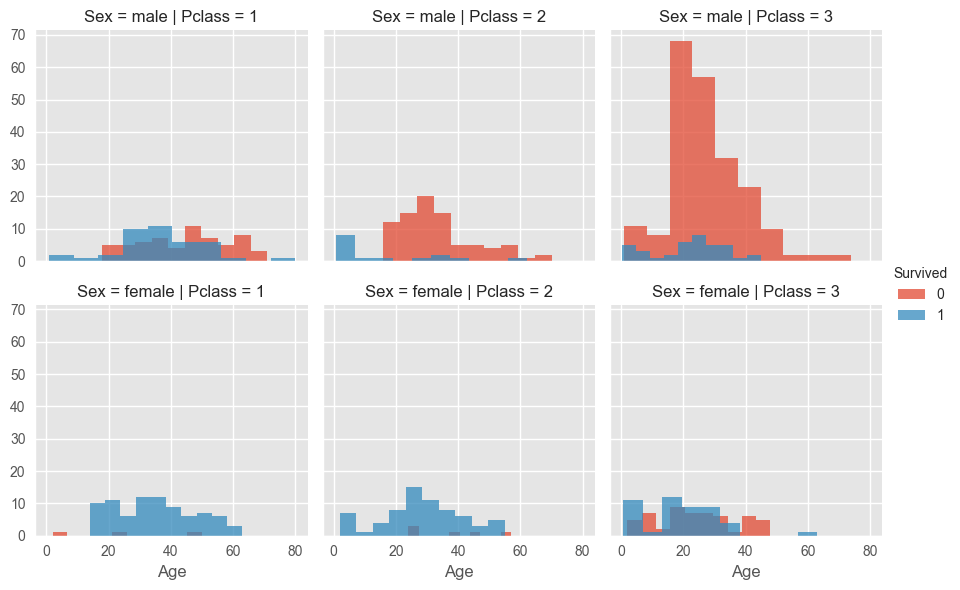

In [189]:
h = sns.FacetGrid(tit_df, row = 'Sex', col = 'Pclass', hue = 'Survived')
h.map(plt.hist, 'Age', alpha = .75)
h.add_legend()
plt.show()

# **Data Cleaning**

In [190]:
tit_test = pd.read_csv('/kaggle/input/titanic/test.csv')
tit_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [191]:
tit_test.shape

(418, 11)

In [192]:
tit_test.info()

<class 'pandas.core.frame.DataFrame'>

RangeIndex: 418 entries, 0 to 417

Data columns (total 11 columns):

 #   Column       Non-Null Count  Dtype  

---  ------       --------------  -----  

 0   PassengerId  418 non-null    int64  

 1   Pclass       418 non-null    int64  

 2   Name         418 non-null    object 

 3   Sex          418 non-null    object 

 4   Age          332 non-null    float64

 5   SibSp        418 non-null    int64  

 6   Parch        418 non-null    int64  

 7   Ticket       418 non-null    object 

 8   Fare         417 non-null    float64

 9   Cabin        91 non-null     object 

 10  Embarked     418 non-null    object 

dtypes: float64(2), int64(4), object(5)

memory usage: 36.0+ KB


In [193]:
tit_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [194]:
tit_df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


***Drop Unwanted Cols***

In [195]:
tit_df.drop(['PassengerId', 'Cabin', 'Ticket'], axis=1, inplace=True)

### **Age, Emarked and Cabin columns contain null values in the training dataset, We will use Statistical Method to fill the null values**

***We will replace age with median***

In [196]:
median_age = tit_df['Age'].median()
tit_df['Age'].fillna(median_age, inplace=True)

***We will replace Embarked with the mode***

In [197]:
embarked_mode = tit_df['Embarked'].mode()[0]
tit_df['Embarked'].fillna(embarked_mode, inplace=True)

In [198]:
tit_df.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [199]:
tit_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [200]:
tit_test.describe(include='all')

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418,418,332.000000,418.000000,418.000000,418,417.000000,91,418
unique,NaN,NaN,418,2,NaN,NaN,NaN,363,NaN,76,3
top,NaN,NaN,"Kelly, Mr. James",male,NaN,NaN,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,1,266,NaN,NaN,NaN,5,NaN,3,270
mean,1100.500000,2.265550,NaN,NaN,30.272590,0.447368,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.841838,NaN,NaN,14.181209,0.896760,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,1.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,3.000000,NaN,NaN,27.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.500000,NaN,NaN


In [201]:
tit_test.drop(['PassengerId', 'Cabin', 'Ticket'], axis=1, inplace=True)

In [202]:
tit_test.isnull().sum()

Pclass       0
Name         0
Sex          0
Age         86
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64

In [203]:
median_age = tit_test['Age'].median()
tit_test['Age'].fillna(median_age, inplace=True)
fare_median = tit_test['Fare'].median()
tit_test['Fare'].fillna(fare_median, inplace=True)

In [204]:
tit_test.isnull().sum()

Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

# **Feature Engineering**

In [205]:
tit_df['FamilySize'] = tit_df['SibSp'] + tit_df['Parch'] + 1
tit_test['FamilySize'] = tit_test['SibSp'] + tit_test['Parch'] + 1
tit_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,2
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,2
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,1


In [206]:
tit_test.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,3,"Kelly, Mr. James",male,34.5,0,0,7.8292,Q,1
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,7.0000,S,2
2,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,9.6875,Q,1
3,3,"Wirz, Mr. Albert",male,27.0,0,0,8.6625,S,1
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,12.2875,S,3


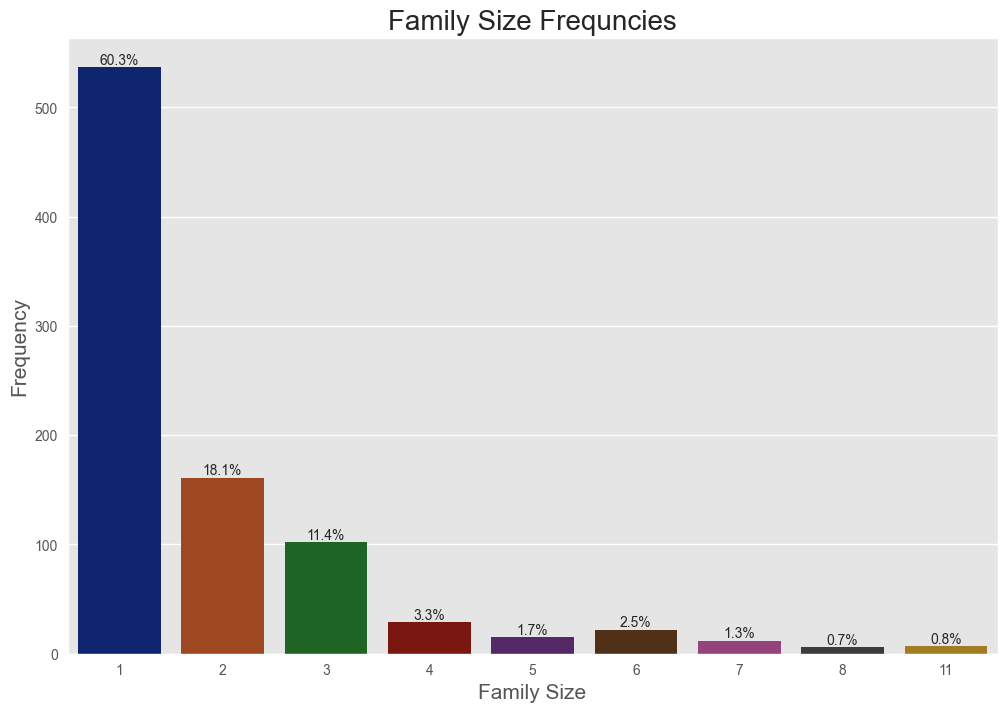

In [207]:
x = tit_df['FamilySize']
count_plot(x, tit_df, "Family Size Frequncies", "Family Size", "Frequency", 12,8, palette='dark')

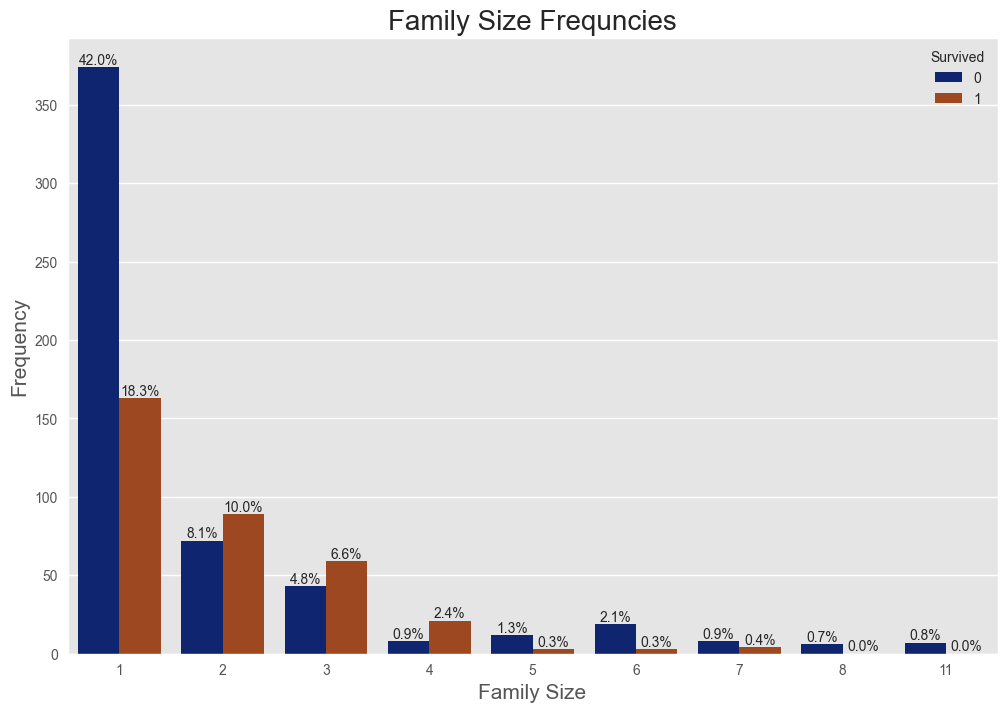

In [208]:
x = tit_df['FamilySize']
hue = tit_df['Survived']
count_plot(x, tit_df, "Family Size Frequncies", "Family Size", "Frequency", 12,8, palette='dark', hue=hue)

In [209]:
tit_df['IsAlone'] = 1
tit_df['IsAlone'].loc[tit_df['FamilySize']>1]=0
tit_test['IsAlone'] = 1
tit_test['IsAlone'].loc[tit_test['FamilySize']>1]=0

In [210]:
tit_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,2,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,2,0
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,1,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,2,0
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,1,1


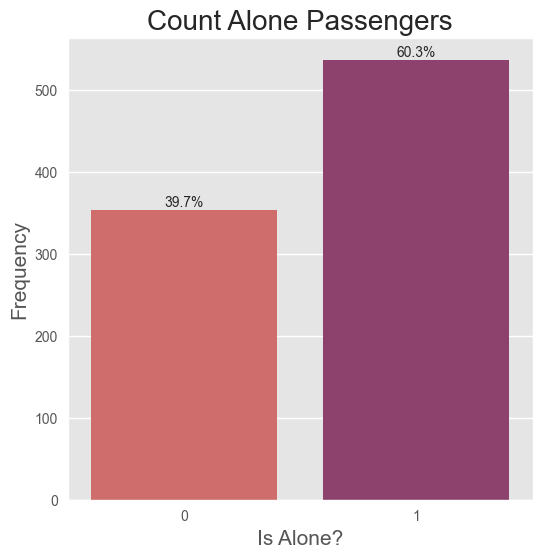

In [211]:
x = tit_df['IsAlone']
count_plot(x, tit_df, "Count Alone Passengers", "Is Alone?", "Frequency", 6,6, palette='flare')

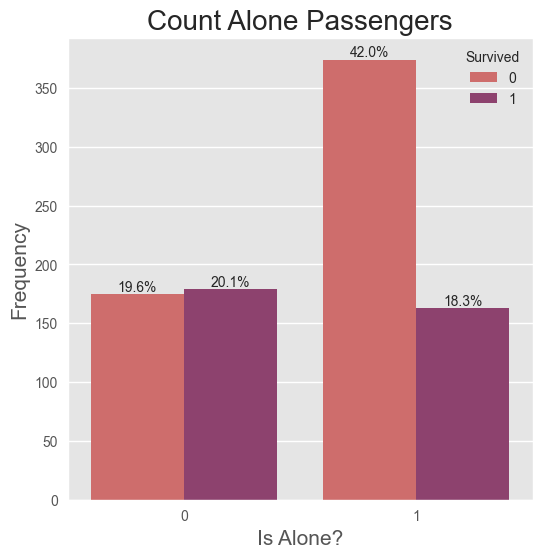

In [212]:
x = tit_df['IsAlone']
hue = tit_df['Survived']
count_plot(x, tit_df, "Count Alone Passengers", "Is Alone?", "Frequency", 6,6, palette='flare', hue=hue)

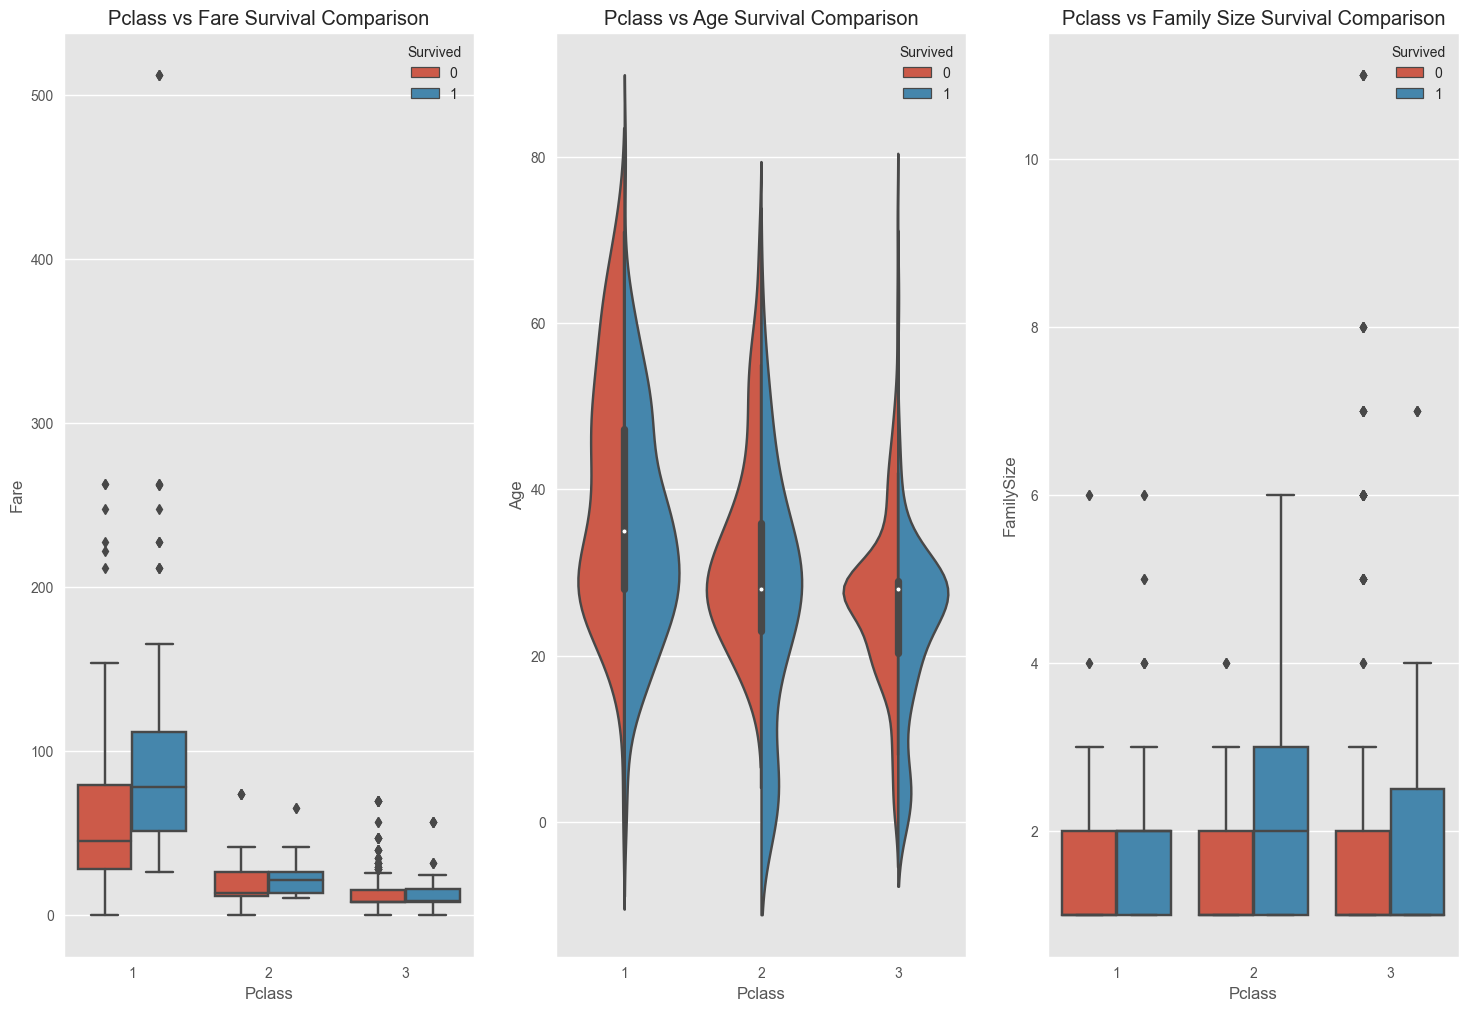

In [213]:
fig, (axis1,axis2,axis3) = plt.subplots(1,3,figsize=(18,12))

sns.boxplot(x = 'Pclass', y = 'Fare', hue = 'Survived', data = tit_df, ax = axis1)
axis1.set_title('Pclass vs Fare Survival Comparison')

sns.violinplot(x = 'Pclass', y = 'Age', hue = 'Survived', data = tit_df, split = True, ax = axis2)
axis2.set_title('Pclass vs Age Survival Comparison')

sns.boxplot(x = 'Pclass', y ='FamilySize', hue = 'Survived', data = tit_df, ax = axis3)
axis3.set_title('Pclass vs Family Size Survival Comparison')
plt.show()

In [214]:
tit_df['Name'].str.split(', ')

0                              [Braund, Mr. Owen Harris]
1      [Cumings, Mrs. John Bradley (Florence Briggs T...
2                               [Heikkinen, Miss. Laina]
3         [Futrelle, Mrs. Jacques Heath (Lily May Peel)]
4                             [Allen, Mr. William Henry]
                             ...                        
886                              [Montvila, Rev. Juozas]
887                       [Graham, Miss. Margaret Edith]
888           [Johnston, Miss. Catherine Helen "Carrie"]
889                              [Behr, Mr. Karl Howell]
890                                [Dooley, Mr. Patrick]
Name: Name, Length: 891, dtype: object

In [215]:
tit_df['Name'].str.split(', ', expand=True)[1].str.split('.')

0                                 [Mr,  Owen Harris]
1      [Mrs,  John Bradley (Florence Briggs Thayer)]
2                                     [Miss,  Laina]
3              [Mrs,  Jacques Heath (Lily May Peel)]
4                               [Mr,  William Henry]
                           ...                      
886                                   [Rev,  Juozas]
887                          [Miss,  Margaret Edith]
888                [Miss,  Catherine Helen "Carrie"]
889                               [Mr,  Karl Howell]
890                                   [Mr,  Patrick]
Name: 1, Length: 891, dtype: object

In [216]:
tit_df['Title'] = tit_df['Name'].str.split(', ', expand=True)[1].str.split('.', expand=True)[0]
tit_test['Title'] = tit_test['Name'].str.split(', ', expand=True)[1].str.split('.', expand=True)[0]

In [217]:
tit_df['Title'].value_counts()

Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: Title, dtype: int64

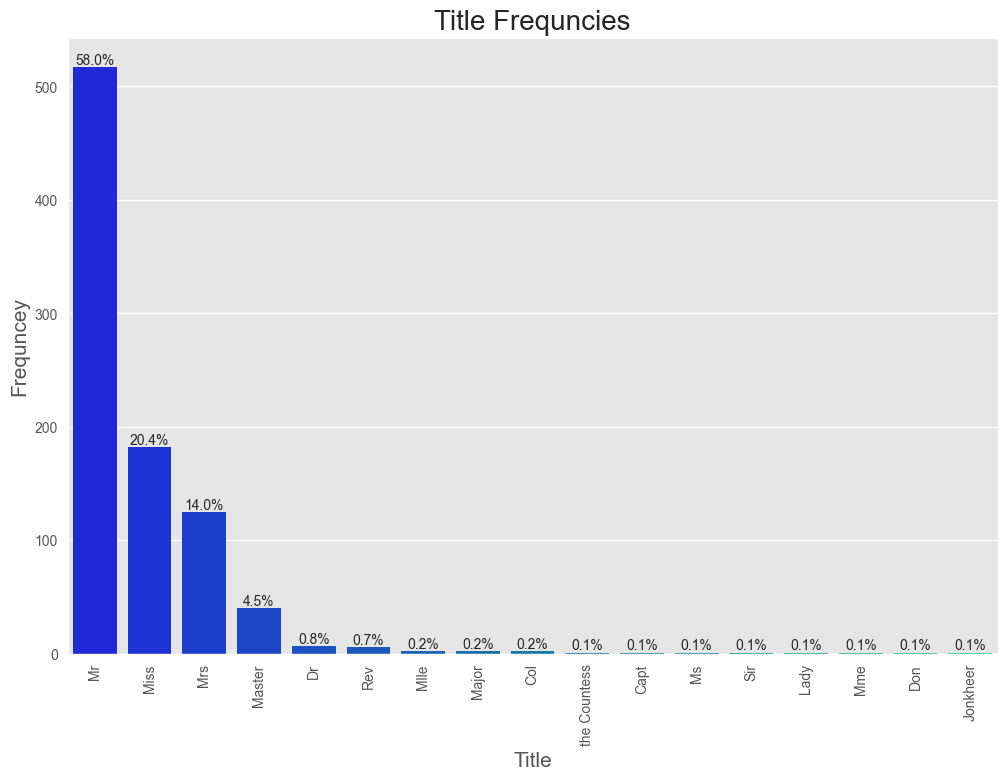

In [218]:
x = tit_df['Title']
order = tit_df['Title'].value_counts().index
count_plot(x, tit_df, "Title Frequncies", "Title", "Frequncey", 12,8, rotation=True, order=order)

**We need to Keep consistency in the data so we will use netural gender title for all unique titles**

In [219]:
stat_min = 10 
title_names = (tit_df['Title'].value_counts() < stat_min)
tit_df['Title'] = tit_df['Title'].apply(lambda x: 'Misc' if title_names.loc[x] == True else x)

title_names = (tit_test['Title'].value_counts() < stat_min)
tit_test['Title'] = tit_test['Title'].apply(lambda x: 'Misc' if title_names.loc[x] == True else x)

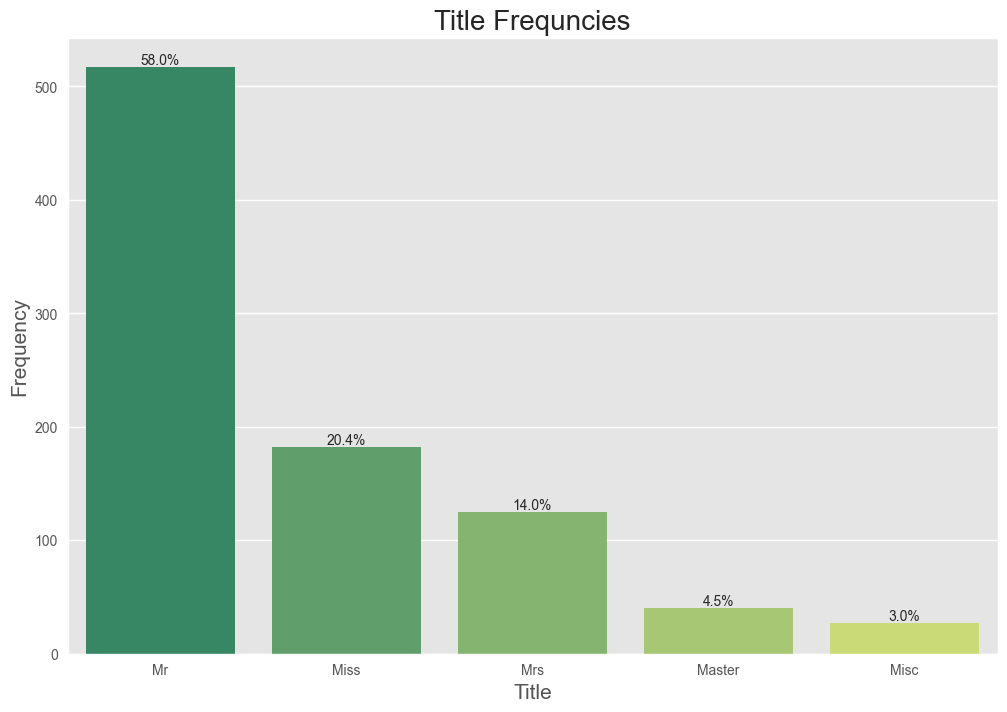

In [220]:
x = tit_df['Title']
order = tit_df['Title'].value_counts().index
count_plot(x, tit_df, "Title Frequncies", "Title", "Frequency", 12,8, palette='summer', order=order)

**Misc Here is a neutral gender title**

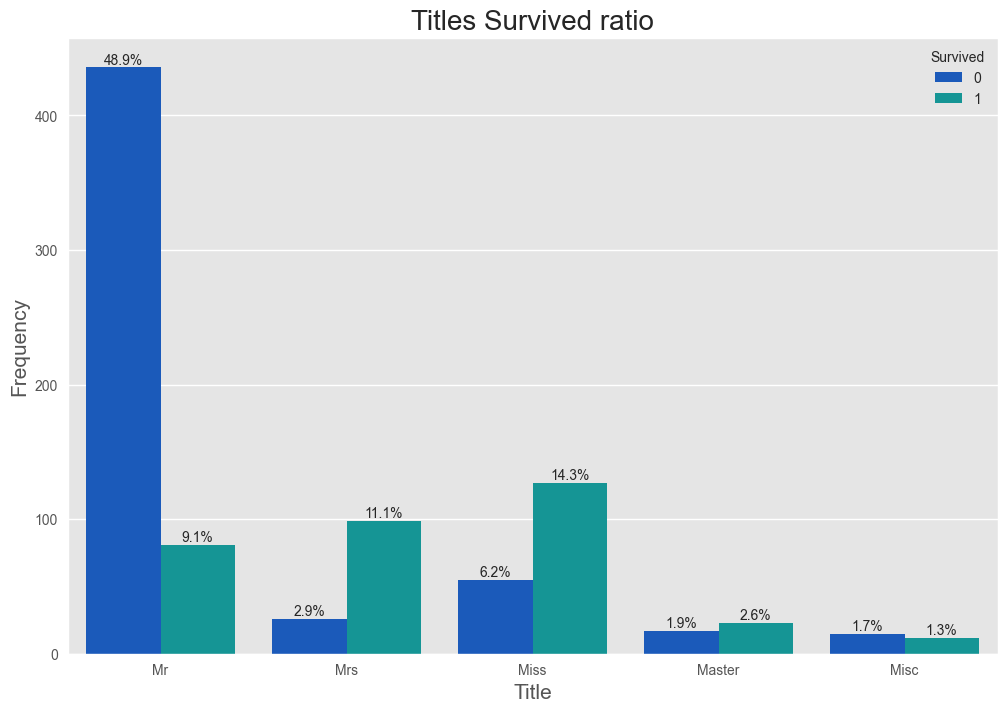

In [221]:
x = tit_df['Title']
hue = tit_df['Survived']
count_plot(x, tit_df, "Titles Survived ratio", "Title", "Frequency", 12,8, hue=hue)

### **As we know previsouly there is more females survived more males**

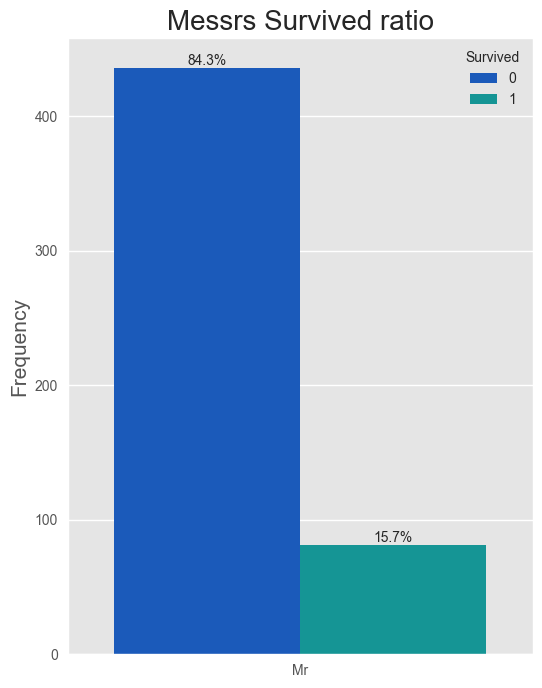

In [222]:
mr_df = tit_df[tit_df['Title'] == 'Mr']
x = mr_df['Title']
hue = mr_df['Survived']
count_plot(x, mr_df, "Messrs Survived ratio", "", "Frequency", 6,8, hue=hue)

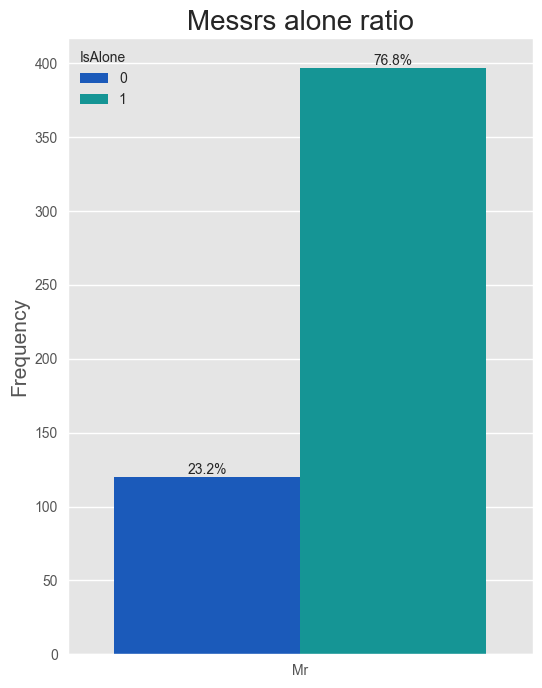

In [223]:
mr_df = tit_df[tit_df['Title'] == 'Mr']
x = mr_df['Title']
hue = mr_df['IsAlone']
count_plot(x, mr_df, "Messrs alone ratio", "", "Frequency", 6,8, hue=hue)

### **77% of the men are alone**

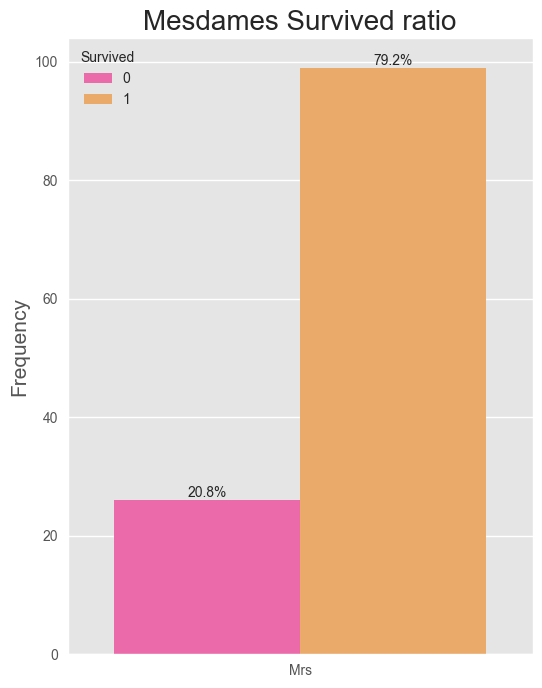

In [224]:
mrs_df = tit_df[tit_df['Title'] == 'Mrs']
x = mrs_df['Title']
hue = mrs_df['Survived']
count_plot(x, mrs_df, "Mesdames Survived ratio", "", "Frequency", 6,8, hue=hue, palette='spring')

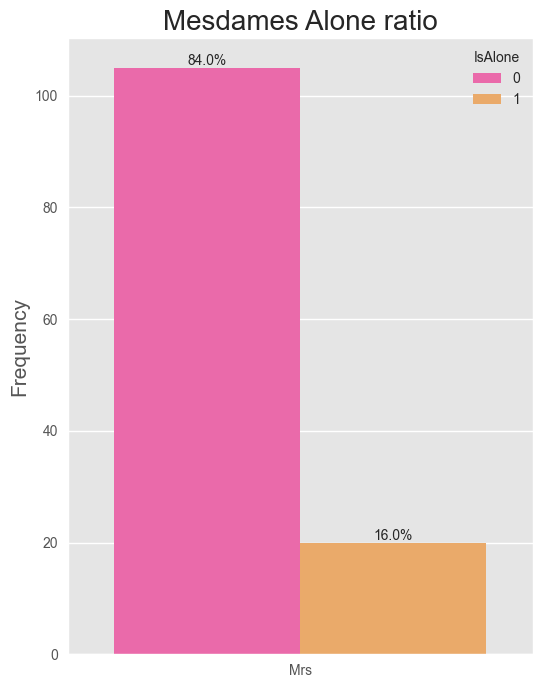

In [225]:
mrs_df = tit_df[tit_df['Title'] == 'Mrs']
x = mrs_df['Title']
hue = mrs_df['IsAlone']
count_plot(x, mrs_df, "Mesdames Alone ratio", "", "Frequency", 6,8, hue=hue, palette='spring')

### **84% of the married women did not go alone**

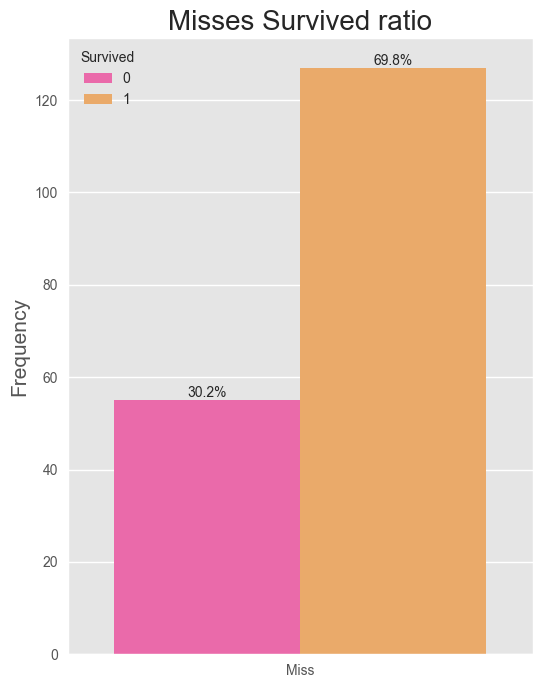

In [226]:
mriss_df = tit_df[tit_df['Title'] == 'Miss']
x = mriss_df['Title']
hue = mriss_df['Survived']
count_plot(x, mriss_df, "Misses Survived ratio", "", "Frequency", 6,8, hue=hue, palette='spring')

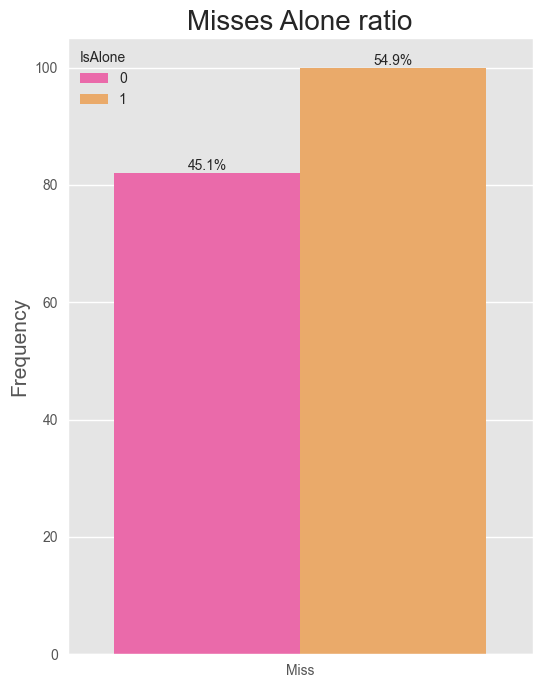

In [227]:
mriss_df = tit_df[tit_df['Title'] == 'Miss']
x = mriss_df['Title']
hue = mriss_df['IsAlone']
count_plot(x, mriss_df, "Misses Alone ratio", "", "Frequency", 6,8, hue=hue, palette='spring')

### **55% of young unmarried ladies didn't go alone but were accompanied by someone**

### **The precentage of survived married women is higher than the precentage of survived unmarried women** 

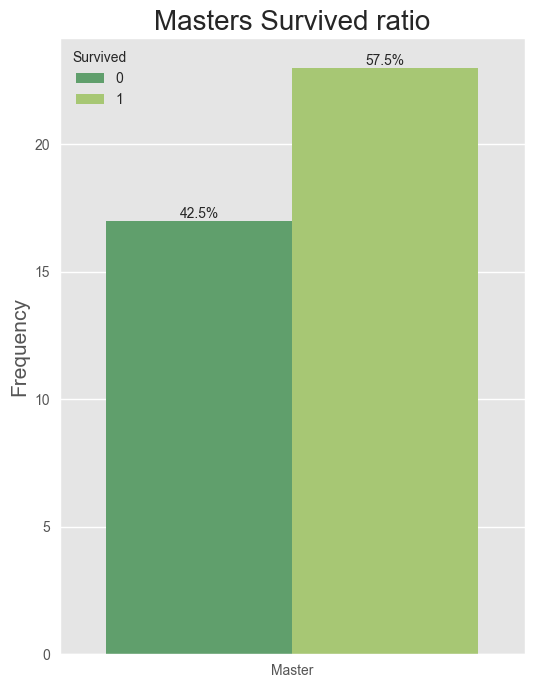

In [228]:
master_df = tit_df[tit_df['Title'] == 'Master']
x = master_df['Title']
hue = master_df['Survived']
count_plot(x, master_df, "Masters Survived ratio", "", "Frequency", 6,8, hue=hue, palette='summer')

## **Precntage of Masters survived are slightly above the doomed**
***Master is a male under 18 years old***

In [229]:
tit_df['FareBin'] = pd.qcut(tit_df['Fare'], 4)
tit_test['FareBin'] = pd.qcut(tit_test['Fare'], 4)
tit_df['AgeBin'] = pd.cut(tit_df['Age'].astype(int), 5)
tit_test['AgeBin'] = pd.cut(tit_test['Age'].astype(int), 5)

# **Data Preprocessing**

In [230]:
tit_df2 = tit_df.copy()

In [231]:
label = LabelEncoder()
tit_df2['Sex_Code'] = label.fit_transform(tit_df2['Sex'])
tit_df2['Embarked_Code'] = label.fit_transform(tit_df2['Embarked'])
tit_df2['Title_Code'] = label.fit_transform(tit_df2['Title'])
tit_df2['AgeBin_Code'] = label.fit_transform(tit_df2['AgeBin'])
tit_df2['FareBin_Code'] = label.fit_transform(tit_df2['FareBin'])

In [232]:
tit_df3 = tit_df2.copy()

In [233]:
features_to_use = ['Sex_Code','Pclass', 'Embarked_Code', 'Title_Code', 'FamilySize', 'AgeBin_Code', 'FareBin_Code', 'Survived']

In [234]:
tit_df3 = tit_df3[features_to_use]

In [235]:
tit_df3.shape

(891, 8)

In [236]:
tit_df3.head()

,Sex_Code,Pclass,Embarked_Code,Title_Code,FamilySize,AgeBin_Code,FareBin_Code,Survived
0,1,3,2,3,2,1,0,0
1,0,1,0,4,2,2,3,1
2,0,3,2,2,1,1,1,1
3,0,1,2,4,2,2,3,1
4,1,3,2,3,1,2,1,0


In [237]:
tit_df3.isnull().sum()

Sex_Code         0
Pclass           0
Embarked_Code    0
Title_Code       0
FamilySize       0
AgeBin_Code      0
FareBin_Code     0
Survived         0
dtype: int64

In [238]:
tit_test2 = tit_test.copy()

In [239]:
tit_test2['Sex_Code'] = label.fit_transform(tit_test2['Sex'])
tit_test2['Embarked_Code'] = label.fit_transform(tit_test2['Embarked'])
tit_test2['Title_Code'] = label.fit_transform(tit_test2['Title'])
tit_test2['AgeBin_Code'] = label.fit_transform(tit_test2['AgeBin'])
tit_test2['FareBin_Code'] = label.fit_transform(tit_test2['FareBin'])

In [240]:
features_to_use = ['Sex_Code','Pclass', 'Embarked_Code', 'Title_Code', 'FamilySize', 'AgeBin_Code', 'FareBin_Code']

In [241]:
tit_test3 = tit_test2.copy()
tit_test3 = tit_test3[features_to_use]

In [242]:
tit_test3.head()

,Sex_Code,Pclass,Embarked_Code,Title_Code,FamilySize,AgeBin_Code,FareBin_Code
0,1,3,1,3,1,2,0
1,0,3,2,4,2,3,0
2,1,2,1,3,1,4,1
3,1,3,2,3,1,1,1
4,0,3,2,4,3,1,1


In [243]:
tit_test3.shape

(418, 7)

In [244]:
tit_test3.isnull().sum()

Sex_Code         0
Pclass           0
Embarked_Code    0
Title_Code       0
FamilySize       0
AgeBin_Code      0
FareBin_Code     0
dtype: int64

# **Pycaret Modeling**

In [245]:
s = setup(data = tit_df3, target = 'Survived', session_id=123)

,Description,Value
0,Session id,123
1,Target,Survived
2,Target type,Binary
3,Original data shape,"(891, 8)"
4,Transformed data shape,"(891, 8)"
5,Transformed train set shape,"(623, 8)"
6,Transformed test set shape,"(268, 8)"
7,Numeric features,7
8,Preprocess,True
9,Imputation type,simple


In [246]:
best_model = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8233,0.8634,0.6900,0.8240,0.7464,0.6134,0.6223,0.0750
lightgbm,Light Gradient Boosting Machine,0.8217,0.8538,0.7109,0.8041,0.7516,0.6138,0.6190,0.0670
ada,Ada Boost Classifier,0.8200,0.8642,0.7654,0.7664,0.7636,0.6185,0.6210,0.0750
rf,Random Forest Classifier,0.8153,0.8436,0.7069,0.7909,0.7446,0.6011,0.6049,0.0960
qda,Quadratic Discriminant Analysis,0.8152,0.8577,0.7737,0.7513,0.7610,0.6105,0.6123,0.0560
xgboost,Extreme Gradient Boosting,0.8121,0.8426,0.6944,0.7934,0.7376,0.5928,0.5985,0.1750
knn,K Neighbors Classifier,0.8057,0.8339,0.7111,0.7653,0.7348,0.5823,0.5853,0.2690
et,Extra Trees Classifier,0.8056,0.8296,0.6817,0.7830,0.7266,0.5776,0.5824,0.1000
dt,Decision Tree Classifier,0.8040,0.8128,0.6692,0.7862,0.7216,0.5725,0.5777,0.0530
lr,Logistic Regression,0.8008,0.8587,0.7156,0.7627,0.7327,0.5750,0.5809,0.7070


In [247]:
print(best_model)

GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,

                           learning_rate=0.1, loss='log_loss', max_depth=3,

                           max_features=None, max_leaf_nodes=None,

                           min_impurity_decrease=0.0, min_samples_leaf=1,

                           min_samples_split=2, min_weight_fraction_leaf=0.0,

                           n_estimators=100, n_iter_no_change=None,

                           random_state=123, subsample=1.0, tol=0.0001,

                           validation_fraction=0.1, verbose=0,

                           warm_start=False)


In [248]:
pred = best_model.predict(tit_test3)
pred

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [249]:
submit_file = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')

In [250]:
submit_file.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [251]:
submit_file.drop('Survived', axis=1,inplace=True)

In [252]:
submit_file['Survived'] = pred

In [253]:
submit_file.to_csv("Submission.csv")